**Imports + settings**

In [1]:
# Cell 1 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [6]:
# nicer plots default size
plt.rcParams['figure.figsize'] = (9,5)
pd.set_option('display.max_columns', 50)

**Load the data**

In [5]:
#Load CSV
df = pd.read_csv(r"C:\Users\Om\Downloads\ott_funnel_dataset.csv",parse_dates=['event_time'])
df.head(10)


,event_time,user_id,session_id,event_type,device_type,os,country,referral_source,is_returning_user,user_age_group,user_gender,content_id,genre,plan_selected,price_selected,payment_method,session_duration_seconds,event_date,event_hour,weekday
0,2025-04-30 21:08:15,U50425,S100425,Visit_Content,Desktop,Linux,India,Organic,0,25-34,Other,C1991,Drama,NaN,NaN,NaN,18,2025-04-30,21,Wednesday
1,2025-05-01 11:03:55,U50991,S100991,Visit_Content,Mobile,Android,Spain,Organic,1,18-24,Female,C1587,Action,NaN,NaN,NaN,1820,2025-05-01,11,Thursday
2,2025-05-01 12:08:37,U50984,S100984,Visit_Content,Mobile,iOS,India,Referral,0,25-34,Other,C1058,Romance,NaN,NaN,NaN,1967,2025-05-01,12,Thursday
3,2025-05-01 12:14:41,U50984,S100984,Click_Subscribe,Mobile,iOS,India,Referral,0,25-34,Other,C1058,Romance,NaN,NaN,NaN,1967,2025-05-01,12,Thursday
4,2025-05-01 12:17:07,U50984,S100984,Select_Plan,Mobile,iOS,India,Referral,0,25-34,Other,C1058,Romance,Monthly,7.99,NaN,1967,2025-05-01,12,Thursday
5,2025-05-01 12:17:45,U50984,S100984,Start_Payment,Mobile,iOS,India,Referral,0,25-34,Other,C1058,Romance,Monthly,7.99,Wallet,1967,2025-05-01,12,Thursday
6,2025-05-01 12:22:13,U50234,S100234,Visit_Content,Desktop,Windows,India,Organic,1,45-54,Male,C1022,Action,NaN,NaN,NaN,2417,2025-05-01,12,Thursday
7,2025-05-01 18:50:34,U50249,S100249,Visit_Content,Desktop,Windows,India,Email,0,45-54,Other,C1469,Drama,NaN,NaN,NaN,3236,2025-05-01,18,Thursday
8,2025-05-01 19:06:06,U51414,S101414,Visit_Content,SmartTV,FireOS,United Kingdom,Ad,0,18-24,Other,C1789,Kids,NaN,NaN,NaN,944,2025-05-01,19,Thursday
9,2025-05-01 19:15:02,U51414,S101414,Click_Subscribe,SmartTV,FireOS,United Kingdom,Ad,0,18-24,Other,C1789,Kids,NaN,NaN,NaN,944,2025-05-01,19,Thursday


Quick checks & basic cleaning

In [8]:
#Quick info and basic cleaning
print("Rows, Columns:", df.shape)
print("Event types:", df['event_type'].unique())

Rows, Columns: (2500, 20)
Event types: ['Visit_Content' 'Click_Subscribe' 'Select_Plan' 'Start_Payment'
 'Payment_Success']


In [9]:
# Fill NA for readability
df['plan_selected'] = df['plan_selected'].fillna('None')
df['payment_method'] = df['payment_method'].fillna('None')
df['price_selected'] = df['price_selected'].fillna(0.0)

In [10]:
# ensure event_time is datetime
df['event_time'] = pd.to_datetime(df['event_time'])

In [11]:
# derived columns
df['event_date'] = df['event_time'].dt.date
df['event_hour'] = df['event_time'].dt.hour
df['weekday'] = df['event_time'].dt.day_name()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   event_time                2500 non-null   datetime64[ns]
 1   user_id                   2500 non-null   object        
 2   session_id                2500 non-null   object        
 3   event_type                2500 non-null   object        
 4   device_type               2500 non-null   object        
 5   os                        2500 non-null   object        
 6   country                   2500 non-null   object        
 7   referral_source           2500 non-null   object        
 8   is_returning_user         2500 non-null   int64         
 9   user_age_group            2500 non-null   object        
 10  user_gender               2500 non-null   object        
 11  content_id                2500 non-null   object        
 12  genre               

In [12]:
df['event_type'].value_counts()


event_type
Visit_Content      1436
Click_Subscribe     360
Select_Plan         360
Start_Payment       223
Payment_Success     121
Name: count, dtype: int64

In [14]:
# Define funnel stages manually
funnel_counts = {
    'Visit_Content': 1436,
    'Click_Subscribe': 360,
    'Select_Plan': 360,
    'Start_Payment': 223,
    'Payment_Success': 121
}

# Convert to DataFrame
import pandas as pd
funnel_df = pd.DataFrame(list(funnel_counts.items()), columns=['Stage', 'Count'])

# Calculate conversion and drop-off rates
funnel_df['Conversion_%'] = (funnel_df['Count'] / funnel_df['Count'].iloc[0] * 100).round(2)
funnel_df['Dropoff_%'] = funnel_df['Conversion_%'].shift(1) - funnel_df['Conversion_%']
funnel_df.fillna(0, inplace=True)

funnel_df


,Stage,Count,Conversion_%,Dropoff_%
0,Visit_Content,1436,100.00,0.00
1,Click_Subscribe,360,25.07,74.93
2,Select_Plan,360,25.07,0.00
3,Start_Payment,223,15.53,9.54
4,Payment_Success,121,8.43,7.10


**Deepen the analysis**

In [15]:
# Group by device_type and event_type
device_funnel = (
    df.groupby(['device_type', 'event_type'])
    .size()
    .unstack(fill_value=0)
    [['Visit_Content', 'Click_Subscribe', 'Select_Plan', 'Start_Payment', 'Payment_Success']]
)

# Add conversion %
device_funnel['Conversion_%'] = (device_funnel['Payment_Success'] / device_funnel['Visit_Content'] * 100).round(2)
device_funnel.sort_values('Conversion_%', ascending=False)


event_type,Visit_Content,Click_Subscribe,Select_Plan,Start_Payment,Payment_Success,Conversion_%
device_type,,,,,,
Tablet,112,28,28,18,12,10.71
SmartTV,154,42,42,21,14,9.09
Mobile,851,216,216,132,70,8.23
Desktop,319,74,74,52,25,7.84


In [16]:
# Same for countries
country_funnel = (
    df.groupby(['country', 'event_type'])
    .size()
    .unstack(fill_value=0)
    [['Visit_Content', 'Click_Subscribe', 'Select_Plan', 'Start_Payment', 'Payment_Success']]
)
country_funnel['Conversion_%'] = (country_funnel['Payment_Success'] / country_funnel['Visit_Content'] * 100).round(2)
country_funnel.sort_values('Conversion_%', ascending=False).head(10)


event_type,Visit_Content,Click_Subscribe,Select_Plan,Start_Payment,Payment_Success,Conversion_%
country,,,,,,
Brazil,107,30,30,22,14,13.08
Spain,62,15,15,11,8,12.90
United States,283,61,61,39,25,8.83
India,645,163,163,98,52,8.06
United Kingdom,117,29,29,17,9,7.69
Germany,56,18,18,12,4,7.14
Australia,84,21,21,12,5,5.95
Canada,82,23,23,12,4,4.88


**Plan-wise Funnel Analysis**

In [17]:
# Funnel by plan
plan_funnel = (
    df.groupby(['plan_selected', 'event_type'])
    .size()
    .unstack(fill_value=0)
    [['Visit_Content', 'Click_Subscribe', 'Select_Plan', 'Start_Payment', 'Payment_Success']]
)
plan_funnel['Conversion_%'] = (plan_funnel['Payment_Success'] / plan_funnel['Visit_Content'] * 100).round(2)
plan_funnel.sort_values('Conversion_%', ascending=False)


event_type,Visit_Content,Click_Subscribe,Select_Plan,Start_Payment,Payment_Success,Conversion_%
plan_selected,,,,,,
FreeTrial,0,0,59,24,14,inf
Monthly,0,0,223,154,78,inf
Yearly,0,0,78,45,29,inf
None,1436,360,0,0,0,0.0


**Handle the “inf” and missing values**

In [26]:
import numpy as np

pivot_df = pivot_df.replace([np.inf, -np.inf], 0)
pivot_df = pivot_df.fillna(0)


**Build overall funnel chart**

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Assuming 'pivot_df' is your plan-wise table or the one with counts
funnel_counts = {
    'Visit_Content': 1436,
    'Click_Subscribe': 360,
    'Select_Plan': 360,
    'Start_Payment': 223,
    'Payment_Success': 121
}

funnel_df = pd.DataFrame(list(funnel_counts.items()), columns=['Stage', 'Users'])

# Funnel visualization
fig = px.funnel(funnel_df, x='Users', y='Stage', title='Overall User Conversion Funnel')
fig.show()


**Plan-wise comparison**

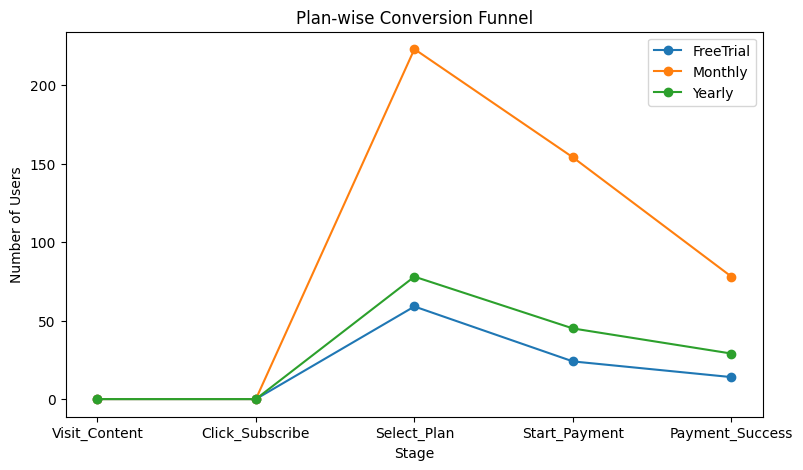

In [31]:
plans = ['FreeTrial', 'Monthly', 'Yearly']

for plan in plans:
    plan_data = pivot_df.loc[plan, ['Visit_Content','Click_Subscribe','Select_Plan','Start_Payment','Payment_Success']]
    plt.plot(plan_data.index, plan_data.values, marker='o', label=plan)

plt.title('Plan-wise Conversion Funnel')
plt.xlabel('Stage')
plt.ylabel('Number of Users')
plt.legend()
plt.show()


**Device-wise funnel (table + funnel chart per device)**

In [32]:
# Device-wise funnel counts & conversion %
device_funnel = df.groupby(['device_type','event_type']).size().unstack(fill_value=0)
stages = ['Visit_Content','Click_Subscribe','Select_Plan','Start_Payment','Payment_Success']
device_funnel = device_funnel.reindex(columns=stages, fill_value=0)
device_funnel['Conversion_%'] = (device_funnel['Payment_Success'] / device_funnel['Visit_Content'] * 100).round(2)
device_funnel = device_funnel.sort_values('Conversion_%', ascending=False)
device_funnel


event_type,Visit_Content,Click_Subscribe,Select_Plan,Start_Payment,Payment_Success,Conversion_%
device_type,,,,,,
Tablet,112,28,28,18,12,10.71
SmartTV,154,42,42,21,14,9.09
Mobile,851,216,216,132,70,8.23
Desktop,319,74,74,52,25,7.84


**Interactive funnels per device (Plotly)**

In [34]:
import plotly.express as px
for device in device_funnel.index:
    vals = device_funnel.loc[device, stages].values
    fig = px.funnel(
        x = vals,
        y = stages,
        title = f"Funnel for {device} (Conversion {device_funnel.loc[device,'Conversion_%']}%)"
    )
    fig.show()



**Country-wise top converting (table + bar)**

In [35]:
country_funnel = df.groupby(['country','event_type']).size().unstack(fill_value=0).reindex(columns=stages, fill_value=0)
country_funnel['Conversion_%'] = (country_funnel['Payment_Success'] / country_funnel['Visit_Content'] * 100).round(2)
country_top = country_funnel.sort_values('Conversion_%', ascending=False).head(10)
country_top[['Visit_Content','Payment_Success','Conversion_%']]
# Bar chart
import plotly.express as px
fig = px.bar(country_top.reset_index(), x='country', y='Conversion_%', title='Top 10 Countries by Conversion %')
fig.show()


**Plan-wise funnel comparison (line chart)**

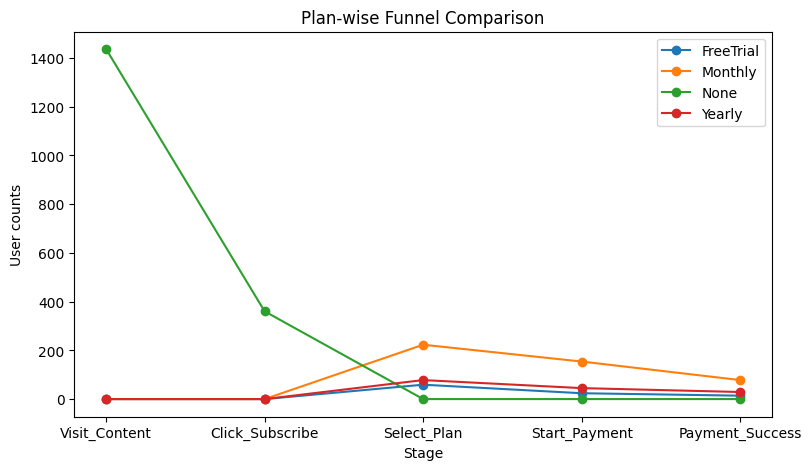

In [36]:
# Make sure a plan-selected pivot exists
plan_pivot = df[df['event_type'].isin(stages)].pivot_table(index='plan_selected', columns='event_type', values='user_id', aggfunc='count', fill_value=0)
plan_pivot = plan_pivot.reindex(columns=stages, fill_value=0)
plan_pivot['Conversion_%'] = (plan_pivot['Payment_Success'] / plan_pivot['Visit_Content'] * 100).round(2)
plan_pivot

# Line comparison (matplotlib)
import matplotlib.pyplot as plt
for plan in plan_pivot.index:
    vals = plan_pivot.loc[plan, stages].values
    plt.plot(stages, vals, marker='o', label=str(plan))
plt.title('Plan-wise Funnel Comparison')
plt.xlabel('Stage')
plt.ylabel('User counts')
plt.legend()
plt.show()


In [38]:
funnel_df.to_csv('cleaned_data.csv', index=False)


In [39]:
df.to_csv(r"C:\Users\Om\Downloads\cleaned_ott_funnel_data.csv", index=False)
